Para cada dataset em dataset/tratado:

1. Carregar dataset tratado

2. Definir configuração do dataset
   - variável alvo
   - atributo sensível
   - grupo privilegiado
   - label favorável
   - label desfavorável

3. Separar treino/teste

4. Modelos
   4.1 Modelo nulo
   4.2 Modelo base
   4.3 Modelo com FairShap

5. Avaliação
   - acurácia
   - precisão
   - recall
   - F1-score
   - Equal Opportunity
   - Equalized Odds
   - Demographic Parity, se fizer sentido

6. Explicabilidade dos modelos
   - SHAP do modelo base
   - SHAP do modelo com FairShap
   - comparação entre importâncias

7. Explicabilidade da mitigação
   - distribuição dos pesos FairShap
   - boxplot por grupo sensível e target
   - árvore de decisão predizendo pesos
   - SHAP da árvore que explica os pesos

# A. Preparação dos Dados, Mitigação e Treinamento dos Modelos

Este bloco executa a etapa principal de preparação dos experimentos.

Para cada conjunto de dados tratado são realizadas as seguintes etapas:

1. Carregamento do dataset.
2. Definição das configurações do experimento.
3. Separação entre conjuntos de treino e teste.
4. Treinamento do modelo nulo.
5. Treinamento do modelo base.
6. Cálculo dos pesos FairShap para cada configuração sensível.
7. Treinamento dos modelos mitigados utilizando os pesos FairShap.
8. Salvamento dos artefatos produzidos para reutilização nas etapas posteriores.

Ao final desta etapa estarão disponíveis todos os modelos treinados, os pesos de mitigação e os conjuntos de treino e teste utilizados nos experimentos.

## Base, Mitigação de pré processamento e durante processamento

In [30]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import json
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
import importlib
import func_aux
from tqdm import tqdm

importlib.reload(func_aux)
from func_aux import *


pasta_tratados = Path("datasets/tratado")
pasta_resultados = Path("resultados")

pasta_modelos = pasta_resultados / "modelos"
pasta_splits = pasta_resultados / "splits"
pasta_mitigacoes_fairshap = pasta_resultados / "mitigacoes" / "fairshap"

for pasta in [pasta_modelos, pasta_splits, pasta_mitigacoes_fairshap]:
    pasta.mkdir(parents=True, exist_ok=True)

with open("configs_datasets.json", "r") as f:
    configs = json.load(f)

arquivos = list(pasta_tratados.glob("*.csv"))

sobrescrever = False  # True para reprocessar mesmo se os arquivos já existirem


for caminho in tqdm(arquivos, desc="Datasets", unit="dataset"):

    nome_dataset = caminho.stem.lower()
    print(f"\nDataset: {nome_dataset}")

    df = pd.read_csv(caminho)

    if "hmda" in nome_dataset:
        df = df.sample(n=25000, random_state=42).reset_index(drop=True)

    config_dataset = configs[nome_dataset]
    configs_sensiveis = config_dataset["configs_sensiveis"]
    target_col = config_dataset["target"]

    # ======================================================
    # Splits
    # ======================================================

    caminho_X_train = pasta_splits / f"{nome_dataset}_X_train.csv"
    caminho_X_test = pasta_splits / f"{nome_dataset}_X_test.csv"
    caminho_y_train = pasta_splits / f"{nome_dataset}_y_train.csv"
    caminho_y_test = pasta_splits / f"{nome_dataset}_y_test.csv"

    if (
        sobrescrever
        or not caminho_X_train.exists()
        or not caminho_X_test.exists()
        or not caminho_y_train.exists()
        or not caminho_y_test.exists()
    ):

        print("Gerando splits...")

        X = df.drop(columns=[target_col])
        y = df[target_col]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.30,
            random_state=42,
            stratify=y
        )

        # FairShap espera índices sequenciais
        X_train = X_train.reset_index(drop=True)
        X_test = X_test.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
        y_test = y_test.reset_index(drop=True)

        X_train.to_csv(caminho_X_train, index=False)
        X_test.to_csv(caminho_X_test, index=False)
        y_train.to_csv(caminho_y_train, index=False)
        y_test.to_csv(caminho_y_test, index=False)

    else:

        print("Splits já existem. Carregando...")

        X_train = pd.read_csv(caminho_X_train)
        X_test = pd.read_csv(caminho_X_test)
        y_train = pd.read_csv(caminho_y_train).iloc[:, 0]
        y_test = pd.read_csv(caminho_y_test).iloc[:, 0]

    # ======================================================
    # Modelo nulo
    # ======================================================

    caminho_modelo_nulo = pasta_modelos / f"{nome_dataset}_nulo.joblib"

    if sobrescrever or not caminho_modelo_nulo.exists():

        print("Treinando modelo nulo...")

        modelo_n = modelo_nulo(
            X_train,
            X_test,
            y_train,
            y_test,
            label="Modelo nulo",
            save_path=caminho_modelo_nulo
        )

    else:
        print("Modelo nulo já existe. Pulando.")

    # ======================================================
    # Modelo base
    # ======================================================

    caminho_modelo_base = pasta_modelos / f"{nome_dataset}_base.joblib"

    if sobrescrever or not caminho_modelo_base.exists():

        print("Treinando modelo base...")

        modelo_b = modelo_base(
            X_train,
            X_test,
            y_train,
            y_test,
            label="Modelo base",
            save_path=caminho_modelo_base
        )

    else:
        print("Modelo base já existe. Pulando.")

    # ======================================================
    # Mitigações por atributo sensível
    # ======================================================

    for config in configs_sensiveis:

        nome_config = config["nome"]
        atributo_sensivel = config["atributo_sensivel"]

        print(f"\nConfig sensível: {nome_config}")

        sensitive_train = X_train[atributo_sensivel].values
        sensitive_test = X_test[atributo_sensivel].values

        # ======================================================
        # FAGTB - in-processing
        # ======================================================

        caminho_modelo_fagtb = (
            pasta_modelos / f"{nome_dataset}_fagtb_{nome_config}.joblib"
        )

        if sobrescrever or not caminho_modelo_fagtb.exists():

            print(f"Treinando FAGTB: {nome_config}")

            modelo_fg = modelo_fagtb(
                X_train,
                y_train.values,
                sensitive_train,
                X_test=X_test,
                y_test=y_test.values,
                sensitive_test=sensitive_test,
                lambda_fagtb=config["lambda_fagtb"]
            )

            joblib.dump(modelo_fg, caminho_modelo_fagtb)

        else:
            print(f"FAGTB já existe. Pulando: {nome_config}")

        # ======================================================
        # FairShap - pre-processing
        # ======================================================

        caminho_pesos = (
            pasta_mitigacoes_fairshap /
            f"{nome_dataset}_pesos_{nome_config}.csv"
        )

        caminho_modelo_fairshap = (
            pasta_modelos / f"{nome_dataset}_fairshap_{nome_config}.joblib"
        )

        # -----------------------------
        # Pesos FairShap
        # -----------------------------

        if sobrescrever or not caminho_pesos.exists():

            print(f"Calculando pesos FairShap: {nome_config}")

            pesos_f, _ = pesos_fairshap(
                X_train,
                X_test,
                y_train,
                y_test,
                protected_attribute_col=atributo_sensivel,
                privileged_value=config["grupo_privilegiado"],
                unprivileged_value=config["grupo_desprivilegiado"],
                label_favorable=1,
                label_unfavorable=0
            )

            pd.DataFrame({"peso_fairshap": pesos_f}).to_csv(
                caminho_pesos,
                index=False
            )

        else:

            print(f"Pesos FairShap já existem. Carregando: {nome_config}")

            pesos_f = pd.read_csv(caminho_pesos)["peso_fairshap"]

        # -----------------------------
        # Modelo FairShap
        # -----------------------------

        if sobrescrever or not caminho_modelo_fairshap.exists():

            print(f"Treinando modelo FairShap: {nome_config}")

            modelo_f = modelo_base(
                X_train,
                X_test,
                y_train,
                y_test,
                weights=pesos_f,
                label=f"FairShap - {nome_config}",
                save_path=caminho_modelo_fairshap
            )

        else:
            print(f"Modelo FairShap já existe. Pulando: {nome_config}")

    print("Concluído.\n")

Arquivo exportado: func_aux.py


Datasets:   0%|          | 0/2 [00:00<?, ?dataset/s]


Dataset: compas
Splits já existem. Carregando...
Modelo nulo já existe. Pulando.
Modelo base já existe. Pulando.

Config sensível: african_american_0
Treinando FAGTB: african_american_0
0 225.27758404148346 2971.1690515310274 3038.752326743472 Accuracy: 0.5445  test :  0.5446  Prule Train :  1.0  Prule test :  1.0
5 3180.205232226385 2955.4749091813765 3909.5364788492925 Accuracy: 0.5445  test :  0.5446  Prule Train :  1.0  Prule test :  1.0
10 3811.646564279209 2938.282114748853 4081.776084032616 Accuracy: 0.5445  test :  0.5446  Prule Train :  1.0  Prule test :  1.0
15 1891.858893282356 2922.1156994288062 3489.673367413513 Accuracy: 0.5445  test :  0.5446  Prule Train :  1.0  Prule test :  1.0
20 4771.5739675710165 2904.9721460023957 4336.4443362737 Accuracy: 0.5445  test :  0.5446  Prule Train :  1.0  Prule test :  1.0
25 1549.4020659639962 2889.4084397630186 3354.229059552217 Accuracy: 0.5445  test :  0.5446  Prule Train :  1.0  Prule test :  1.0
30 4198.735908103988 2873.62665514

Datasets:  50%|█████     | 1/2 [00:05<00:05,  5.90s/dataset]

Pesos FairShap já existem. Carregando: caucasian_1
Modelo FairShap já existe. Pulando: caucasian_1
Concluído.


Dataset: hmda
Splits já existem. Carregando...
Modelo nulo já existe. Pulando.
Modelo base já existe. Pulando.

Config sensível: african_american_0
Treinando FAGTB: african_american_0
0 23362.601288465925 9128.313111166302 9151.67571245477 Accuracy: 0.7836  test :  0.7836  Prule Train :  1.0  Prule test :  1.0
5 9599.888222154446 9067.964027313004 9077.56391553516 Accuracy: 0.7836  test :  0.7836  Prule Train :  1.0  Prule test :  1.0
10 18415.5430985337 9008.684962539892 9027.100505638426 Accuracy: 0.7836  test :  0.7836  Prule Train :  1.0  Prule test :  1.0
15 54910.41816679735 8950.45152659909 9005.36194476589 Accuracy: 0.7836  test :  0.7836  Prule Train :  1.0  Prule test :  1.0
20 63338.657721986325 8893.217615716265 8956.55627343825 Accuracy: 0.7836  test :  0.7836  Prule Train :  1.0  Prule test :  1.0
25 48381.49488218697 8836.971484006934 8885.35297888912 Accuracy:

Datasets: 100%|██████████| 2/2 [01:10<00:00, 35.30s/dataset]

Pesos FairShap já existem. Carregando: caucasian_1
Modelo FairShap já existe. Pulando: caucasian_1
Concluído.



## Mitigação de Pós processamento: ThresholdOptimizer

In [6]:
# ============================================================
# BLOCO A - Pós-processamento com ThresholdOptimizer
# Equalized Odds aplicado ao modelo base
# ============================================================

import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split
from fairlearn.postprocessing import ThresholdOptimizer


# ============================================================
# Wrapper para ThresholdOptimizer
# ============================================================

class ThresholdWrapper:
    """
    Wrapper para fazer o ThresholdOptimizer funcionar como modelo comum.

    Permite usar:
        modelo.predict(X)
        modelo.predict_proba(X)

    O atributo sensível é guardado internamente.
    """

    def __init__(self, modelo_threshold, atributo_sensivel, feature_names=None):
        self.modelo_threshold = modelo_threshold
        self.atributo_sensivel = atributo_sensivel
        self.feature_names = list(feature_names) if feature_names is not None else None

        # Metadados úteis para análise depois
        self.tipo_modelo = "threshold"
        self.mitigacao = "post_equalized_odds"

    def _garantir_dataframe(self, X):
        """
        Garante que X seja DataFrame.

        Isso ajuda principalmente no SHAP, que às vezes passa numpy array.
        """
        if isinstance(X, pd.DataFrame):
            return X.copy()

        if self.feature_names is None:
            raise ValueError(
                "X veio como array, mas feature_names não foi definido no wrapper."
            )

        return pd.DataFrame(X, columns=self.feature_names)

    def predict(self, X):
        X_df = self._garantir_dataframe(X)

        if self.atributo_sensivel not in X_df.columns:
            raise ValueError(
                f"Atributo sensível '{self.atributo_sensivel}' não encontrado em X."
            )

        return self.modelo_threshold.predict(
            X_df,
            sensitive_features=X_df[self.atributo_sensivel]
        )

    def predict_proba(self, X):
        """
        Compatibiliza com sklearn/SHAP.

        Atenção: esta não é uma probabilidade contínua real.
        É uma representação da decisão final pós-processada:
            classe 0 -> [1, 0]
            classe 1 -> [0, 1]
        """
        y_pred = np.asarray(self.predict(X)).astype(int)

        return np.column_stack([
            1 - y_pred,
            y_pred
        ])

    def get_threshold_model(self):
        return self.modelo_threshold

    def get_sensitive_attribute(self):
        return self.atributo_sensivel


# ============================================================
# Pastas
# ============================================================

pasta_resultados = Path("resultados")
pasta_modelos = pasta_resultados / "modelos"
pasta_splits = pasta_resultados / "splits"
pasta_post = pasta_resultados / "mitigacoes" / "threshold"

pasta_post.mkdir(parents=True, exist_ok=True)

caminho_configs = Path("configs_datasets.json")

sobrescrever = True  # True para reprocessar mesmo se os arquivos já existirem


# ============================================================
# Carrega configs dos datasets
# ============================================================

with open(caminho_configs, "r", encoding="utf-8") as f:
    configs_datasets = json.load(f)


# ============================================================
# Pós-processamento
# ============================================================

for nome_dataset, config_dataset in configs_datasets.items():

    print("\n" + "=" * 80)
    print(f"Dataset: {nome_dataset}")
    print("=" * 80)

    # --------------------------------------------------------
    # Busca modelo base
    # --------------------------------------------------------

    modelos_base = list(pasta_modelos.glob(f"{nome_dataset}_*base*.joblib"))

    modelos_base = [
        caminho for caminho in modelos_base
        if "post" not in caminho.stem.lower()
        and "threshold" not in caminho.stem.lower()
    ]

    if not modelos_base:
        print(f"Nenhum modelo base encontrado para {nome_dataset}.")
        continue

    if len(modelos_base) > 1:
        print("Mais de um modelo base encontrado. Usando o primeiro:")
        for m in modelos_base:
            print(f" - {m.name}")

    caminho_base = modelos_base[0]
    print(f"Modelo base usado: {caminho_base.name}")

    modelo_base = joblib.load(caminho_base)

    # --------------------------------------------------------
    # Carrega treino salvo em CSV
    # --------------------------------------------------------

    X_train = pd.read_csv(pasta_splits / f"{nome_dataset}_X_train.csv")
    y_train = pd.read_csv(pasta_splits / f"{nome_dataset}_y_train.csv").squeeze()

    # --------------------------------------------------------
    # Cria validação a partir do treino
    # --------------------------------------------------------

    _, X_valid, _, y_valid = train_test_split(
        X_train,
        y_train,
        test_size=0.2,
        stratify=y_train,
        random_state=42
    )

    # --------------------------------------------------------
    # Configurações sensíveis do dataset
    # --------------------------------------------------------

    configs_sensiveis = config_dataset["configs_sensiveis"]

    for config in configs_sensiveis:

        nome_config = config["nome"]
        atributo_sensivel = config["atributo_sensivel"]

        print(f"\nConfig sensível: {nome_config}")
        print(f"Atributo sensível: {atributo_sensivel}")

        if atributo_sensivel not in X_valid.columns:
            print(f"Atributo {atributo_sensivel} não encontrado em X_valid. Pulando.")
            continue

        A_valid = X_valid[atributo_sensivel]

        # ----------------------------------------------------
        # Nome de saída
        # ----------------------------------------------------

        nome_saida = f"{nome_dataset}_threshold_{nome_config}.joblib"
        caminho_saida = pasta_modelos / nome_saida

        if caminho_saida.exists() and not sobrescrever:
            print(f"Já existe, pulando: {nome_saida}")
            continue

        # ----------------------------------------------------
        # Cria modelo pós-processado
        # ----------------------------------------------------

        modelo_post = ThresholdOptimizer(
            estimator=modelo_base,
            constraints="equalized_odds",
            objective="balanced_accuracy_score",
            predict_method="predict_proba",
            prefit=True
        )

        # ----------------------------------------------------
        # Aprende thresholds no conjunto de validação
        # ----------------------------------------------------

        modelo_post.fit(
            X_valid,
            y_valid,
            sensitive_features=A_valid
        )

        # ----------------------------------------------------
        # Embrulha o ThresholdOptimizer
        # ----------------------------------------------------

        modelo_wrapper = ThresholdWrapper(
            modelo_threshold=modelo_post,
            atributo_sensivel=atributo_sensivel,
            feature_names=X_valid.columns
        )

        modelo_wrapper.nome_dataset = nome_dataset
        modelo_wrapper.nome_config = nome_config
        modelo_wrapper.modelo_original = caminho_base.name

        # ----------------------------------------------------
        # Salva modelo wrapper
        # ----------------------------------------------------

        joblib.dump(modelo_wrapper, caminho_saida)

        print("Modelo threshold wrapper salvo em:")
        print(caminho_saida)

        # ----------------------------------------------------
        # Salva regras/thresholds aprendidos
        # ----------------------------------------------------

        try:
            regras = modelo_post.interpolated_thresholder_.interpolation_dict

            df_regras = pd.DataFrame([
                {
                    "dataset": nome_dataset,
                    "modelo_original": caminho_base.name,
                    "mitigacao": "post_equalized_odds",
                    "config_sensivel": nome_config,
                    "atributo_sensivel": atributo_sensivel,
                    "grupo": grupo,
                    "regra": str(regra)
                }
                for grupo, regra in regras.items()
            ])

        except Exception as e:
            df_regras = pd.DataFrame([{
                "dataset": nome_dataset,
                "modelo_original": caminho_base.name,
                "mitigacao": "post_equalized_odds",
                "config_sensivel": nome_config,
                "atributo_sensivel": atributo_sensivel,
                "erro_ao_extrair_regras": str(e),
                "objeto_threshold": str(getattr(modelo_post, "interpolated_thresholder_", "não encontrado"))
            }])

        caminho_regras = (
            pasta_post /
            f"{nome_dataset}_threshold_{nome_config}_regras.csv"
        )

        df_regras.to_csv(caminho_regras, index=False)

        print("Regras salvas em:")
        print(caminho_regras)


Dataset: compas
Modelo base usado: compas_base.joblib

Config sensível: african_american_0
Atributo sensível: African-American
Modelo threshold wrapper salvo em:
resultados\modelos\compas_threshold_african_american_0.joblib
Regras salvas em:
resultados\mitigacoes\threshold\compas_threshold_african_american_0_regras.csv

Config sensível: caucasian_1
Atributo sensível: Caucasian
Modelo threshold wrapper salvo em:
resultados\modelos\compas_threshold_caucasian_1.joblib
Regras salvas em:
resultados\mitigacoes\threshold\compas_threshold_caucasian_1_regras.csv

Dataset: hmda
Modelo base usado: hmda_base.joblib

Config sensível: african_american_0
Atributo sensível: Applicant_African-American
Modelo threshold wrapper salvo em:
resultados\modelos\hmda_threshold_african_american_0.joblib
Regras salvas em:
resultados\mitigacoes\threshold\hmda_threshold_african_american_0_regras.csv

Config sensível: caucasian_1
Atributo sensível: Applicant_Caucasian
Modelo threshold wrapper salvo em:
resultados\

# B. Avaliação e Explicabilidade dos Modelos

Este bloco opera sobre os modelos previamente treinados e salvos.

Para cada modelo são realizadas as seguintes análises:

1. Carregamento do modelo e dos conjuntos de teste correspondentes.
2. Avaliação de desempenho preditivo.
3. Avaliação de métricas de justiça algorítmica.
4. Geração das explicações globais utilizando SHAP.
5. Comparação entre as importâncias das variáveis nos modelos base e mitigados.

O objetivo desta etapa é analisar simultaneamente o desempenho preditivo e os efeitos das técnicas de mitigação sobre o comportamento dos modelos.

## Avaliação (1,2,3)

In [14]:
import json
import joblib
import pandas as pd
import numpy as np

from pathlib import Path
from tqdm import tqdm
import importlib

import func_aux
importlib.reload(func_aux)

from func_aux import *

pasta_resultados = Path("resultados")
pasta_modelos = pasta_resultados / "modelos"
pasta_splits = pasta_resultados / "splits"
pasta_metricas = pasta_resultados / "metricas"

pasta_metricas.mkdir(parents=True, exist_ok=True)


with open("configs_datasets.json", "r", encoding="utf-8") as f:
    configs = json.load(f)


resultados_avaliacao = []

caminhos_modelos = list(pasta_modelos.glob("*.joblib"))


for caminho_modelo in tqdm(
    caminhos_modelos,
    desc="Avaliando modelos",
    unit="modelo"
):

    nome_arquivo = caminho_modelo.stem
    nome_dataset = nome_arquivo.split("_")[0]

    config_dataset = configs[nome_dataset]
    configs_sensiveis = config_dataset["configs_sensiveis"]

    modelo = joblib.load(caminho_modelo)

    X_test = pd.read_csv(
        pasta_splits / f"{nome_dataset}_X_test.csv"
    )

    y_test = pd.read_csv(
        pasta_splits / f"{nome_dataset}_y_test.csv"
    ).squeeze()


    # ========================================================
    # Identificação do tipo de modelo e mitigação
    # ========================================================

    if "nulo" in nome_arquivo:

        tipo_modelo = "nulo"
        mitigacao = "nenhuma"

        # Apenas uma configuração sensível para referência
        configs_para_avaliar = [configs_sensiveis[0]]

    elif "base" in nome_arquivo:

        tipo_modelo = "base"
        mitigacao = "nenhuma"

        # Apenas uma configuração sensível para referência
        configs_para_avaliar = [configs_sensiveis[0]]

    elif "fairshap" in nome_arquivo:

        tipo_modelo = "fairshap"
        mitigacao = "fairshap"

        config = [
            c for c in configs_sensiveis
            if c["nome"] in nome_arquivo
        ][0]

        configs_para_avaliar = [config]

    elif "fagtb" in nome_arquivo:

        tipo_modelo = "fagtb"
        mitigacao = "fagtb"

        config = [
            c for c in configs_sensiveis
            if c["nome"] in nome_arquivo
        ][0]

        configs_para_avaliar = [config]

    elif "threshold" in nome_arquivo:

        tipo_modelo = "threshold"
        mitigacao = "threshold"

        config = [
            c for c in configs_sensiveis
            if c["nome"] in nome_arquivo
        ][0]

        configs_para_avaliar = [config]

    else:
        print(f"Modelo ignorado, tipo não identificado: {nome_arquivo}")
        continue


    # ========================================================
    # Avaliação
    # ========================================================

    for config in configs_para_avaliar:

        atributo_sensivel = config["atributo_sensivel"]
        grupo_privilegiado = config["grupo_privilegiado"]
        grupo_desprivilegiado = config["grupo_desprivilegiado"]

        metricas = avaliar_modelo(
            modelo,
            X_test,
            y_test,
            atributo_sensivel=atributo_sensivel,
            grupo_privilegiado=grupo_privilegiado,
            grupo_desprivilegiado=grupo_desprivilegiado
        )

        metricas_ar = taxa_real_por_grupo(
            y_true=y_test,
            sensitive_features=X_test[atributo_sensivel],
            grupo_privilegiado=grupo_privilegiado,
            grupo_desprivilegiado=grupo_desprivilegiado,
            label_favoravel=1
        )

        metricas.update(metricas_ar)

        linha = {
            "dataset": nome_dataset,
            "modelo": tipo_modelo,
            "mitigacao": mitigacao,
            "config_sensivel": config["nome"]
        }

        linha.update(metricas)

        resultados_avaliacao.append(linha)


df_metricas = pd.DataFrame(resultados_avaliacao)


# ========================================================
# Ordenação
# ========================================================

ordem_modelos = {
    "nulo": 0,
    "base": 1,
    "fairshap": 2,
    "fagtb": 3,
    "threshold": 4
}

df_metricas["ordem_modelo"] = df_metricas["modelo"].map(ordem_modelos)

df_metricas = df_metricas.sort_values(
    by=["dataset","ordem_modelo","config_sensivel"]
).drop(columns=["ordem_modelo"])


df_metricas.to_csv(
    pasta_metricas / "metricas_modelos.csv",
    index=False
)

display(df_metricas)

Arquivo exportado: func_aux.py


Avaliando modelos: 100%|██████████| 16/16 [00:04<00:00,  3.23modelo/s]


,dataset,modelo,mitigacao,config_sensivel,accuracy,precision,recall,f1,equal_opportunity,equalized_odds,demographic_parity,tpr_privilegiado,tpr_desprivilegiado,fpr_privilegiado,fpr_desprivilegiado,positive_rate_privilegiado,positive_rate_desprivilegiado,actual_rate_privilegiado,actual_rate_desprivilegiado
5,compas,nulo,nenhuma,african_american_0,0.544571,0.544571,1.000000,0.705142,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.620068,0.475104
0,compas,base,nenhuma,african_american_0,0.682334,0.687835,0.762897,0.723424,0.157690,0.211045,0.251660,0.834545,0.676856,0.572700,0.308300,0.735062,0.483402,0.620068,0.475104
3,compas,fairshap,fairshap,african_american_0,0.660724,0.673993,0.730159,0.700952,0.066376,0.056214,0.011445,0.700000,0.766376,0.394659,0.440711,0.583991,0.595436,0.620068,0.475104
4,compas,fairshap,fairshap,caucasian_1,0.644516,0.665094,0.699405,0.681818,0.233494,0.198991,0.167301,0.555556,0.789050,0.301310,0.465798,0.461039,0.628340,0.628247,0.502834
1,compas,fagtb,fagtb,african_american_0,0.591572,0.575904,0.948413,0.716642,0.002509,0.024902,0.035777,0.947273,0.949782,0.863501,0.816206,0.915445,0.879668,0.620068,0.475104
2,compas,fagtb,fagtb,caucasian_1,0.611561,0.591514,0.926587,0.722072,0.006666,0.068643,0.069391,0.922481,0.929147,0.860262,0.729642,0.899351,0.829960,0.628247,0.502834
6,compas,threshold,threshold,african_american_0,0.661804,0.668430,0.751984,0.707750,0.043112,0.032652,0.031666,0.736364,0.779476,0.456973,0.434783,0.630214,0.598548,0.620068,0.475104
7,compas,threshold,threshold,caucasian_1,0.656942,0.634269,0.874008,0.735086,0.006741,0.048603,0.075628,0.881137,0.874396,0.663755,0.573290,0.800325,0.724696,0.628247,0.502834
13,hmda,nulo,nenhuma,african_american_0,0.783600,0.783600,1.000000,0.878672,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.805175,0.712234
8,hmda,base,nenhuma,african_american_0,0.854267,0.853532,0.982644,0.913549,0.020932,0.037764,0.064041,0.987061,0.966129,0.627451,0.572854,0.916999,0.852958,0.805175,0.712234


In [15]:
from func_aux import exportar_metricas_monografia_xlsx

exportar_metricas_monografia_xlsx(
    df_metricas=df_metricas,
    caminho_saida=pasta_metricas / "metricas_modelos_monografia.xlsx",
    caminho_dicionario="dicionario_tabela_metricas.json",
    casas_decimais=3
)

WindowsPath('resultados/metricas/metricas_modelos_monografia.xlsx')

In [ ]:
import matplotlib.pyplot as plt

def salvar_tabela_como_imagem(df, caminho="tabela.png", titulo=None):
    n_linhas, n_colunas = df.shape

    fig_w = max(10, 1.3 * n_colunas)
    fig_h = max(3, 0.45 * n_linhas + 1.2)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    tabela = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(9)
    tabela.scale(1, 1.3)

    for (row, col), cell in tabela.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")

    if titulo:
        ax.set_title(titulo, fontsize=14, pad=16)

    plt.tight_layout()
    plt.savefig(caminho, dpi=300, bbox_inches="tight")
    plt.close()

In [ ]:
# Exemplo
df_metricas = pd.read_csv(pasta_metricas / "metricas_modelos.csv")
colunas_numericas = df_metricas.select_dtypes(include="number").columns
df_metricas[colunas_numericas] = df_metricas[colunas_numericas].round(3)
salvar_tabela_como_imagem(df_metricas, "tabela_metricas.png", "Métricas dos modelos")

## Explicabilidade (4,5)

In [32]:
import json
import importlib
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import func_aux
importlib.reload(func_aux)
from func_aux import *




pasta_resultados = Path("resultados")
pasta_modelos = pasta_resultados / "modelos"
pasta_splits = pasta_resultados / "splits"

pasta_exp_modelos = pasta_resultados / "explicabilidade" / "modelos"
pasta_exp_modelos.mkdir(parents=True, exist_ok=True)

with open("configs_datasets.json", "r") as f:
    configs = json.load(f)


caminhos_modelos = [
    caminho
    for caminho in pasta_modelos.glob("*.joblib")
    if "nulo" not in caminho.stem
]


for caminho_modelo in tqdm(caminhos_modelos, desc="Gerando SHAP", unit="modelo"):

    nome_modelo = caminho_modelo.stem
    nome_dataset = nome_modelo.split("_")[0]

    config_dataset = configs[nome_dataset]
    cmap = config_dataset.get("shap_cmap", "coolwarm")

    modelo = joblib.load(caminho_modelo)

    X_test = pd.read_csv(
        pasta_splits / f"{nome_dataset}_X_test.csv"
    )

    figuras = explain_model(
        model=modelo,
        X=X_test,
        max_display=15,
        nome=nome_modelo,
        cmap=cmap
    )

    for nome_figura, fig in figuras.items():

        fig.savefig(
            pasta_exp_modelos / f"{nome_modelo}_shap_{nome_figura}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.close("all")


print("SHAP dos modelos gerado e salvo.")

Arquivo exportado: func_aux.py


Gerando SHAP:   0%|          | 0/14 [00:00<?, ?modelo/s]

🔍 Gerando explicabilidade global do modelo...


c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:637: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:652: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
Gerando SHAP:   7%|▋         | 1/14 [00:01<00:16,  1.26s/modelo]

⚠️ Tipo de modelo não suportado pelo TreeExplainer.
🔁 Usando explicabilidade model-agnostic (caixa-preta).


...

⚠️ Tipo de modelo não suportado pelo TreeExplainer.
🔁 Usando explicabilidade model-agnostic (caixa-preta).


PermutationExplainer explainer: 501it [00:37,  9.73it/s]                         
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:637: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:652: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


🔍 Gerando explicabilidade global do modelo...


Gerando SHAP: 100%|██████████| 14/14 [1:27:02<00:00, 373.06s/modelo]

SHAP dos modelos gerado e salvo.


In [17]:
import json
import importlib
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import func_aux
importlib.reload(func_aux)
from func_aux import *


# ============================================================
# Pastas
# ============================================================

pasta_resultados = Path("resultados")
pasta_modelos = pasta_resultados / "modelos"
pasta_splits = pasta_resultados / "splits"

pasta_exp = pasta_resultados / "explicabilidade"
pasta_exp_modelos = pasta_exp / "modelos"
pasta_exp_dados = pasta_exp / "dados_shap"

pasta_exp_modelos.mkdir(parents=True, exist_ok=True)
pasta_exp_dados.mkdir(parents=True, exist_ok=True)


# ============================================================
# Configurações
# ============================================================

with open("configs_datasets.json", "r", encoding="utf-8") as f:
    configs = json.load(f)


sobrescrever = False


# ============================================================
# Função auxiliar para identificar tipo/config do modelo
# ============================================================

def identificar_modelo_e_config(nome_modelo, configs_sensiveis):
    """
    Identifica tipo de modelo, mitigação e configuração sensível
    a partir do nome do arquivo .joblib.
    """

    if "nulo" in nome_modelo:
        return {
            "tipo_modelo": "nulo",
            "mitigacao": "nenhuma",
            "config_sensivel": "referencia"
        }

    if "base" in nome_modelo:
        return {
            "tipo_modelo": "base",
            "mitigacao": "nenhuma",
            "config_sensivel": "referencia"
        }

    if "fairshap" in nome_modelo:
        tipo_modelo = "fairshap"
        mitigacao = "fairshap"

    elif "fagtb" in nome_modelo:
        tipo_modelo = "fagtb"
        mitigacao = "fagtb"

    elif "threshold" in nome_modelo:
        tipo_modelo = "threshold"
        mitigacao = "threshold"

    else:
        return None

    config_encontrada = [
        c for c in configs_sensiveis
        if c["nome"] in nome_modelo
    ]

    if len(config_encontrada) == 0:
        raise ValueError(
            f"Não foi possível identificar config sensível para: {nome_modelo}"
        )

    return {
        "tipo_modelo": tipo_modelo,
        "mitigacao": mitigacao,
        "config_sensivel": config_encontrada[0]["nome"]
    }


# ============================================================
# Modelos a explicar
# ============================================================

caminhos_modelos = [
    caminho
    for caminho in pasta_modelos.glob("*.joblib")
    if "nulo" not in caminho.stem
]


# ============================================================
# Geração das explicações
# ============================================================

metadados_exp = []

for caminho_modelo in tqdm(
    caminhos_modelos,
    desc="Gerando SHAP",
    unit="modelo"
):

    nome_modelo = caminho_modelo.stem
    nome_dataset = nome_modelo.split("_")[0]

    config_dataset = configs[nome_dataset]
    configs_sensiveis = config_dataset["configs_sensiveis"]
    cmap = config_dataset.get("shap_cmap", "coolwarm")

    info_modelo = identificar_modelo_e_config(
        nome_modelo,
        configs_sensiveis
    )

    if info_modelo is None:
        print(f"Modelo ignorado: {nome_modelo}")
        continue

    caminho_exp = pasta_exp_dados / f"{nome_modelo}_exp_shap.joblib"

    # ========================================================
    # Se já existe e não quiser sobrescrever, pula o cálculo
    # ========================================================

    if caminho_exp.exists() and not sobrescrever:
        print(f"Explicação já existe, pulando: {nome_modelo}")

        metadados_exp.append({
            "dataset": nome_dataset,
            "modelo": info_modelo["tipo_modelo"],
            "mitigacao": info_modelo["mitigacao"],
            "config_sensivel": info_modelo["config_sensivel"],
            "nome_arquivo_modelo": nome_modelo,
            "caminho_exp": str(caminho_exp)
        })

        continue

    modelo = joblib.load(caminho_modelo)

    X_test = pd.read_csv(
        pasta_splits / f"{nome_dataset}_X_test.csv"
    )

    figuras, explicacao = explain_model(
        model=modelo,
        X=X_test,
        max_display=15,
        nome=nome_modelo,
        cmap=cmap,
        classe=1,
        explicar_todas_classes=False
    )

    # ========================================================
    # Salva figuras individuais
    # ========================================================

    for nome_figura, fig in figuras.items():

        fig.savefig(
            pasta_exp_modelos / f"{nome_modelo}_shap_{nome_figura}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.close("all")


    # ========================================================
    # Salva somente o necessário para replotar depois
    # Evita salvar o explainer inteiro, que pode ser pesado.
    # ========================================================

    explicacao_salvar = {
        "shap_values": explicacao["shap_values"],
        "X_plot": explicacao["X_plot"],
        "metodo": explicacao["metodo"],
        "dataset": nome_dataset,
        "modelo": info_modelo["tipo_modelo"],
        "mitigacao": info_modelo["mitigacao"],
        "config_sensivel": info_modelo["config_sensivel"],
        "nome_arquivo_modelo": nome_modelo
    }

    joblib.dump(
        explicacao_salvar,
        caminho_exp
    )

    metadados_exp.append({
        "dataset": nome_dataset,
        "modelo": info_modelo["tipo_modelo"],
        "mitigacao": info_modelo["mitigacao"],
        "config_sensivel": info_modelo["config_sensivel"],
        "nome_arquivo_modelo": nome_modelo,
        "caminho_exp": str(caminho_exp)
    })


# ============================================================
# Salva índice das explicações
# ============================================================

df_metadados_exp = pd.DataFrame(metadados_exp)

df_metadados_exp.to_csv(
    pasta_exp_dados / "indice_exp_shap.csv",
    index=False
)

display(df_metadados_exp)

print("SHAP dos modelos gerado e salvo.")

Arquivo exportado: func_aux.py


Gerando SHAP:   0%|          | 0/14 [00:00<?, ?modelo/s]c:\Users\Davi Araujo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Gerando SHAP:   7%|▋         | 1/14 [00:12<02:41, 12.44s/modelo]

⚠️ Tipo de modelo não suportado pelo TreeExplainer.
🔁 Usando explicabilidade model-agnostic (caixa-preta).


PermutationExplainer explainer: 501it [25:30,  3.06s/it]
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1040: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  cmap=plt.get_cmap(cmap),
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1075: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  
Gerando SHAP:  14%|█▍        | 2/14 [25:44<3:01:16, 906.40s/modelo]

⚠️ Tipo de modelo não suportado pelo TreeExplainer.
🔁 Usando explicabilidade model-agnostic (caixa-preta).


...

PermutationExplainer explainer: 501it [00:36,  9.95it/s]
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1040: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  cmap=plt.get_cmap(cmap),
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1075: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  
Gerando SHAP:  93%|█████████▎| 13/14 [1:23:46<03:12, 192.28s/modelo]

⚠️ Tipo de modelo não suportado pelo TreeExplainer.
🔁 Usando explicabilidade model-agnostic (caixa-preta).


PermutationExplainer explainer: 501it [00:36,  9.92it/s]                         
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1040: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  cmap=plt.get_cmap(cmap),
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1075: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  
Gerando SHAP: 100%|██████████| 14/14 [1:24:23<00:00, 361.68s/modelo]


,dataset,modelo,mitigacao,config_sensivel,nome_arquivo_modelo,caminho_exp
0,compas,base,nenhuma,referencia,compas_base,resultados\explicabilidade\dados_shap\compas_b...
1,compas,fagtb,fagtb,african_american_0,compas_fagtb_african_american_0,resultados\explicabilidade\dados_shap\compas_f...
2,compas,fagtb,fagtb,caucasian_1,compas_fagtb_caucasian_1,resultados\explicabilidade\dados_shap\compas_f...
3,compas,fairshap,fairshap,african_american_0,compas_fairshap_african_american_0,resultados\explicabilidade\dados_shap\compas_f...
4,compas,fairshap,fairshap,caucasian_1,compas_fairshap_caucasian_1,resultados\explicabilidade\dados_shap\compas_f...
5,compas,threshold,threshold,african_american_0,compas_threshold_african_american_0,resultados\explicabilidade\dados_shap\compas_t...
6,compas,threshold,threshold,caucasian_1,compas_threshold_caucasian_1,resultados\explicabilidade\dados_shap\compas_t...
7,hmda,base,nenhuma,referencia,hmda_base,resultados\explicabilidade\dados_shap\hmda_bas...
8,hmda,fagtb,fagtb,african_american_0,hmda_fagtb_african_american_0,resultados\explicabilidade\dados_shap\hmda_fag...
9,hmda,fagtb,fagtb,caucasian_1,hmda_fagtb_caucasian_1,resultados\explicabilidade\dados_shap\hmda_fag...


SHAP dos modelos gerado e salvo.


Arquivo exportado: func_aux.py


,dataset,modelo,mitigacao,config_sensivel,nome_arquivo_modelo,caminho_exp
0,compas,base,nenhuma,referencia,compas_base,resultados\explicabilidade\dados_shap\compas_b...
1,compas,fagtb,fagtb,african_american_0,compas_fagtb_african_american_0,resultados\explicabilidade\dados_shap\compas_f...
2,compas,fagtb,fagtb,caucasian_1,compas_fagtb_caucasian_1,resultados\explicabilidade\dados_shap\compas_f...
3,compas,fairshap,fairshap,african_american_0,compas_fairshap_african_american_0,resultados\explicabilidade\dados_shap\compas_f...
4,compas,fairshap,fairshap,caucasian_1,compas_fairshap_caucasian_1,resultados\explicabilidade\dados_shap\compas_f...
5,compas,threshold,threshold,african_american_0,compas_threshold_african_american_0,resultados\explicabilidade\dados_shap\compas_t...
6,compas,threshold,threshold,caucasian_1,compas_threshold_caucasian_1,resultados\explicabilidade\dados_shap\compas_t...
7,hmda,base,nenhuma,referencia,hmda_base,resultados\explicabilidade\dados_shap\hmda_bas...
8,hmda,fagtb,fagtb,african_american_0,hmda_fagtb_african_american_0,resultados\explicabilidade\dados_shap\hmda_fag...
9,hmda,fagtb,fagtb,caucasian_1,hmda_fagtb_caucasian_1,resultados\explicabilidade\dados_shap\hmda_fag...


Seleção de variáveis para gráfico SHAP agrupado
Modelos considerados: ['Base', 'FairShap', 'FAGTB', 'Threshold']
Top por modelo: 7
Variáveis únicas na união dos tops: 10
Limite final de variáveis no gráfico: 10
✅ Todas as variáveis do top de cada modelo foram mantidas.


c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1446: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  modelo.predict(X, sensitive_features=X[atributo_sensivel])


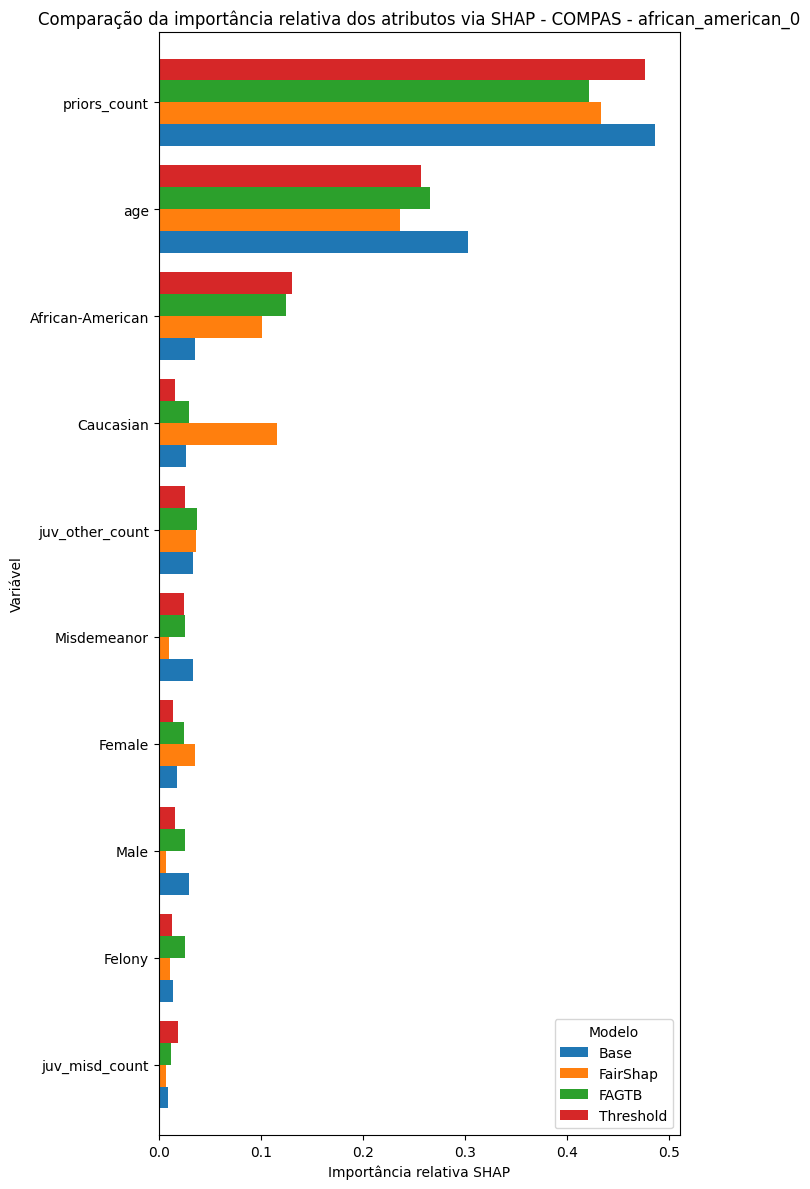

Seleção de variáveis para gráfico SHAP agrupado
Modelos considerados: ['Base', 'FairShap', 'FAGTB', 'Threshold']
Top por modelo: 7
Variáveis únicas na união dos tops: 10
Limite final de variáveis no gráfico: 10
✅ Todas as variáveis do top de cada modelo foram mantidas.


c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1446: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  modelo.predict(X, sensitive_features=X[atributo_sensivel])


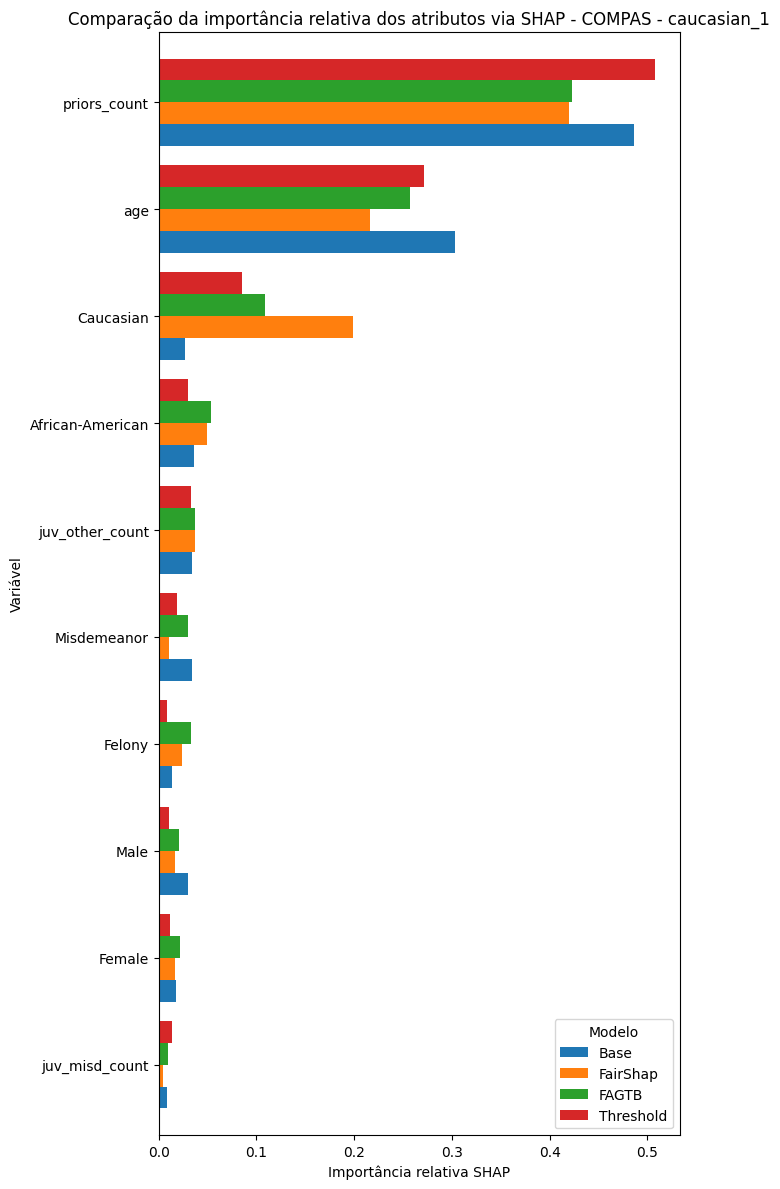

Seleção de variáveis para gráfico SHAP agrupado
Modelos considerados: ['Base', 'FairShap', 'FAGTB', 'Threshold']
Top por modelo: 7
Variáveis únicas na união dos tops: 10
Limite final de variáveis no gráfico: 10
✅ Todas as variáveis do top de cada modelo foram mantidas.


c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1446: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  modelo.predict(X, sensitive_features=X[atributo_sensivel])


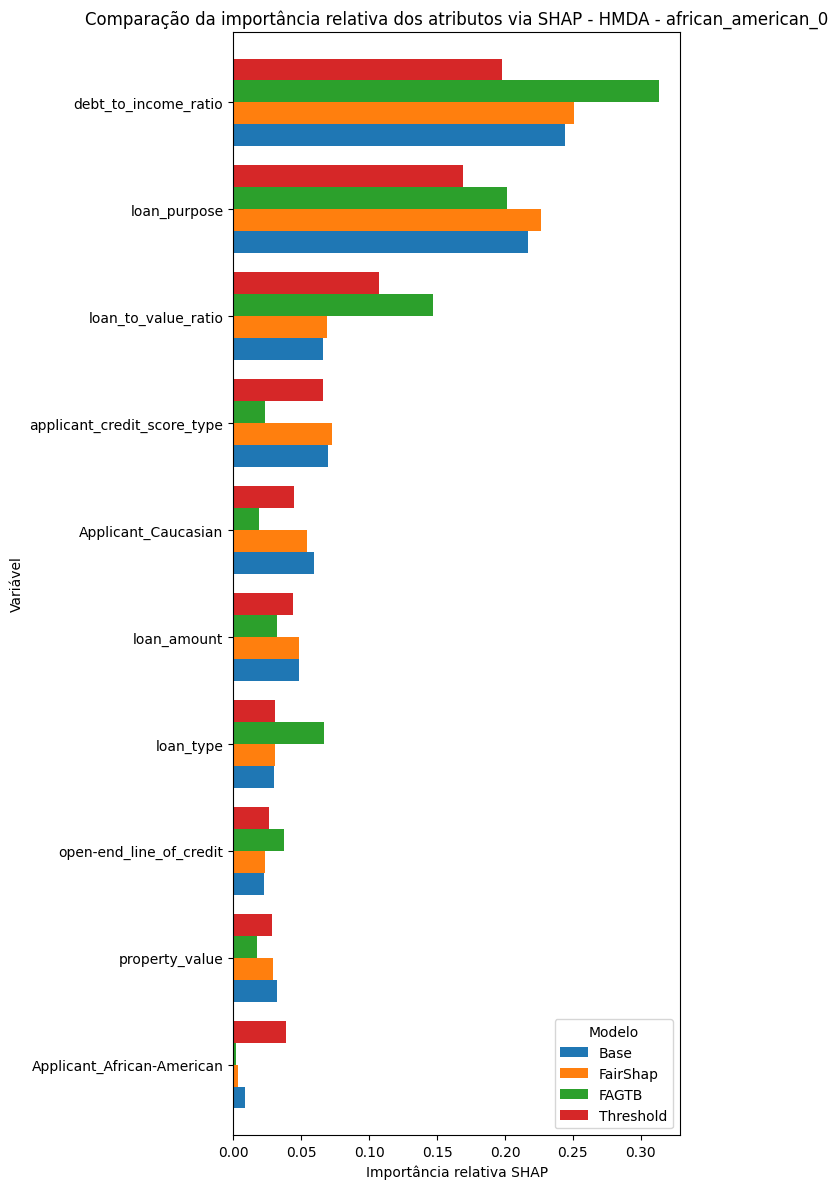

Seleção de variáveis para gráfico SHAP agrupado
Modelos considerados: ['Base', 'FairShap', 'FAGTB', 'Threshold']
Top por modelo: 7
Variáveis únicas na união dos tops: 10
Limite final de variáveis no gráfico: 10
✅ Todas as variáveis do top de cada modelo foram mantidas.


c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:1446: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  modelo.predict(X, sensitive_features=X[atributo_sensivel])


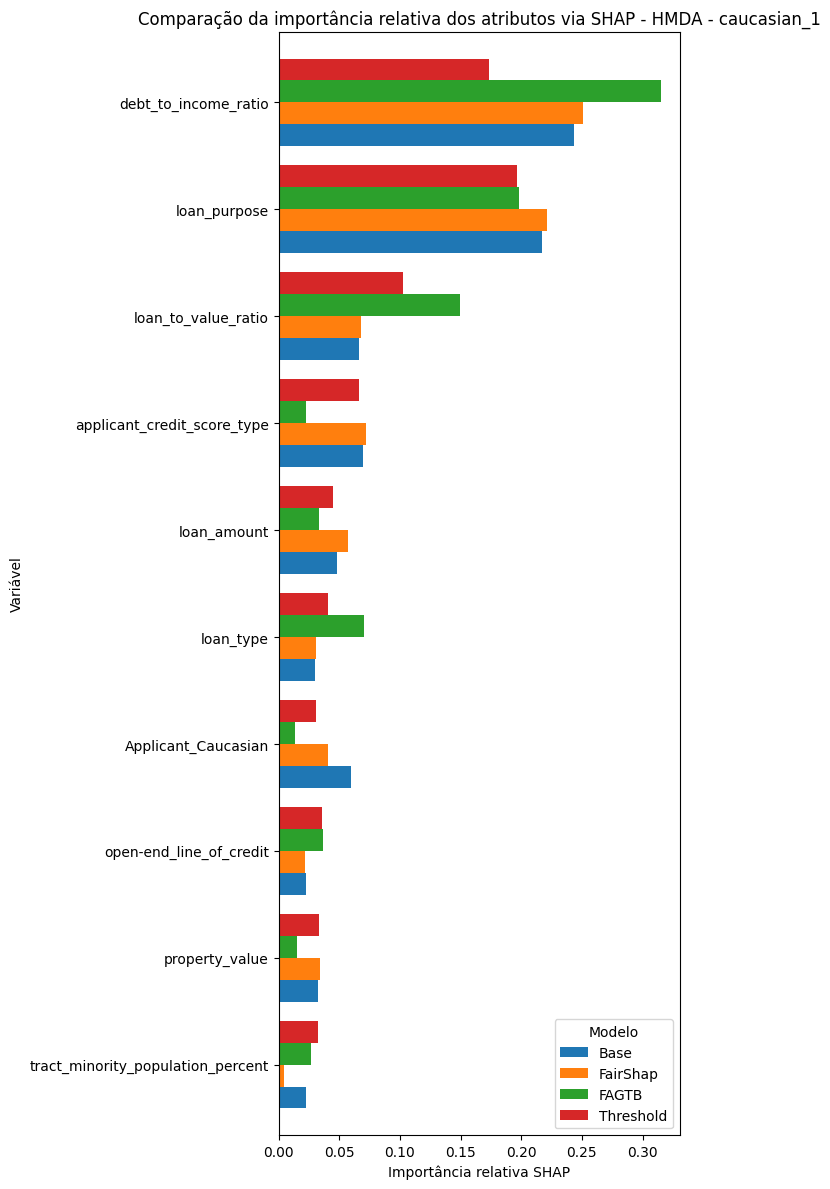

Gráficos SHAP agrupados gerados.


,Posição,Base nome,Base %,FairShap nome,FairShap %,FAGTB nome,FAGTB %,Threshold nome,Threshold %
0,1,debt_to_income_ratio,24.386208,debt_to_income_ratio,25.101104,debt_to_income_ratio,31.513976,loan_purpose,19.676221
1,2,loan_purpose,21.713979,loan_purpose,22.158964,loan_purpose,19.776943,debt_to_income_ratio,17.330775
2,3,applicant_credit_score_type,6.968858,applicant_credit_score_type,7.186954,loan_to_value_ratio,14.968183,loan_to_value_ratio,10.214962
3,4,loan_to_value_ratio,6.608348,loan_to_value_ratio,6.822152,loan_type,7.010745,applicant_credit_score_type,6.643810
4,5,Applicant_Caucasian,5.963716,loan_amount,5.684627,open-end_line_of_credit,3.675967,loan_amount,4.439656
5,6,loan_amount,4.851192,Applicant_Caucasian,4.071740,loan_amount,3.313657,loan_type,4.036974
6,7,property_value,3.218417,property_value,3.423403,tract_minority_population_percent,2.697299,open-end_line_of_credit,3.532739
7,8,loan_type,2.970395,loan_type,3.079802,applicant_credit_score_type,2.247205,property_value,3.361864
8,9,loan_term,2.926580,loan_term,2.709432,loan_term,2.175143,tract_minority_population_percent,3.205118
9,10,CoApplicant_Caucasian,2.602628,CoApplicant_Caucasian,2.686712,income,1.946765,Applicant_Caucasian,3.073319


In [ ]:
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import importlib
import func_aux
importlib.reload(func_aux)
from func_aux import *


# ============================================================
# Pastas
# ============================================================

pasta_resultados = Path("resultados")

pasta_exp = pasta_resultados / "explicabilidade"
pasta_exp_dados = pasta_exp / "dados_shap"
pasta_exp_agrupados = pasta_exp / "modelos_agrupados"

pasta_exp_agrupados.mkdir(parents=True, exist_ok=True)


# ============================================================
# Carrega índice das explicações
# ============================================================

df_exp = pd.read_csv(
    pasta_exp_dados / "indice_exp_shap.csv"
)

display(df_exp)


# ============================================================
# Nomes bonitos para os modelos
# ============================================================

nomes_modelos = {
    "base": "Base",
    "fairshap": "FairShap",
    "fagtb": "FAGTB",
    "threshold": "Threshold"
}


# ============================================================
# Gera gráficos agrupados
# ============================================================

for nome_dataset in df_exp["dataset"].unique():

    df_dataset = df_exp[df_exp["dataset"] == nome_dataset].copy()

    # Explicação do modelo base do dataset
    df_base = df_dataset[df_dataset["modelo"] == "base"]

    if df_base.empty:
        print(f"Sem modelo base para dataset: {nome_dataset}")
        continue

    caminho_base = df_base.iloc[0]["caminho_exp"]
    exp_base = joblib.load(caminho_base)


    # Configurações sensíveis existentes nas mitigações
    configs_sensiveis_dataset = sorted(
        df_dataset[
            df_dataset["modelo"].isin(["fairshap", "fagtb", "threshold"])
        ]["config_sensivel"].dropna().unique()
    )


    for config_sensivel in configs_sensiveis_dataset:

        df_config = df_dataset[
            (
                df_dataset["config_sensivel"] == config_sensivel
            )
            &
            (
                df_dataset["modelo"].isin(["fairshap", "fagtb", "threshold"])
            )
        ].copy()

        explicacoes_por_modelo = {
            "Base": exp_base
        }

        for _, linha in df_config.iterrows():

            modelo_curto = linha["modelo"]
            nome_exibicao = nomes_modelos.get(modelo_curto, modelo_curto)

            exp = joblib.load(linha["caminho_exp"])

            explicacoes_por_modelo[nome_exibicao] = exp


        # Se só tiver Base, não vale plotar
        if len(explicacoes_por_modelo) <= 1:
            print(
                f"Sem mitigações suficientes para {nome_dataset} - {config_sensivel}"
            )
            continue


        titulo = (
            f"Comparação da importância média dos atributos via SHAP "
            f"- {nome_dataset.upper()} - {config_sensivel}"
        )

        caminho_saida = (
            pasta_exp_agrupados /
            f"{nome_dataset}_{config_sensivel}_shap_barras_agrupadas.png"
        )

        df_shap_comparativo, tabela_shap_plot, tabela_ranking = plot_shap_barras_agrupadas(
            explicacoes_por_modelo=explicacoes_por_modelo,
            top_por_modelo=7,
            top_final=10,
            classe=1,
            titulo=(
                f"Comparação da importância relativa dos atributos via SHAP "
                f"- {nome_dataset.upper()} - {config_sensivel}"
            ),
            salvar_em=(
                pasta_exp_agrupados /
                f"{nome_dataset}_{config_sensivel}_shap_barras_agrupadas_relativo.png"
            ),
            salvar_tabela_ranking_em=(
                pasta_exp_agrupados /
                f"{nome_dataset}_{config_sensivel}_shap_ranking_variaveis.csv"
            ),
            figsize=(7, 12),
            normalizar=True,
            ordem_modelos = ["Threshold", "FAGTB", "FairShap", "Base"]
        )

        # Salva também os dados tabulares do gráfico
        df_shap_comparativo.to_csv(
            pasta_exp_agrupados /
            f"{nome_dataset}_{config_sensivel}_shap_importancias_long.csv",
            index=False
        )

        tabela_shap_plot.to_csv(
            pasta_exp_agrupados /
            f"{nome_dataset}_{config_sensivel}_shap_importancias_pivot.csv"
        )

        plt.close("all")


print("Gráficos SHAP agrupados gerados.")
display(tabela_ranking)

# C. Explicabilidade da Mitigação FairShap

Este bloco busca compreender como o FairShap atua sobre os dados através da análise dos pesos gerados pela mitigação.

Para cada configuração sensível são realizadas as seguintes análises:

1. Distribuição global dos pesos.
2. Distribuição dos pesos por grupo sensível.
3. Distribuição dos pesos por grupo sensível e variável alvo.
4. Treinamento de uma árvore de decisão para aproximar os pesos produzidos pelo FairShap.
5. Aplicação de SHAP sobre a árvore para identificar os atributos mais relevantes na geração dos pesos.

O objetivo desta etapa é fornecer uma interpretação qualitativa do mecanismo de mitigação, permitindo compreender quais características dos dados estão sendo privilegiadas ou penalizadas pelo FairShap.

In [33]:
# ============================================================
# C. Explicabilidade da Mitigação FairShap
# ============================================================

import json
import joblib
import importlib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import func_aux
importlib.reload(func_aux)
from func_aux import *


pasta_resultados = Path("resultados")

pasta_splits = pasta_resultados / "splits"
pasta_mitigacoes_fairshap = pasta_resultados / "mitigacoes" / "fairshap"
pasta_exp_mitigacao = pasta_resultados / "explicabilidade" / "mitigacoes" / "fairshap"

pasta_exp_mitigacao.mkdir(parents=True, exist_ok=True)

with open("configs_datasets.json", "r") as f:
    configs = json.load(f)


arquivos_pesos = list(
    pasta_mitigacoes_fairshap.glob("*_pesos_*.csv")
)

metricas_arvores = []


for caminho_pesos in tqdm(
    arquivos_pesos,
    desc="Explicando FairShap",
    unit="config"
):

    nome_arquivo = caminho_pesos.stem

    nome_dataset = nome_arquivo.split("_pesos_")[0]

    config_dataset = configs[nome_dataset]
    configs_sensiveis = config_dataset["configs_sensiveis"]

    config = [
        c for c in configs_sensiveis
        if c["nome"] in nome_arquivo
    ][0]

    cmap = config_dataset.get("shap_cmap", "coolwarm")

    print(f"\nFairShap: {nome_dataset} | {config['nome']}")

    X_train = pd.read_csv(
        pasta_splits / f"{nome_dataset}_X_train.csv"
    )

    y_train = pd.read_csv(
        pasta_splits / f"{nome_dataset}_y_train.csv"
    ).squeeze()

    pesos_fairshap = pd.read_csv(
        caminho_pesos
    )["peso_fairshap"]

    resultado = explicar_pesos_fairshap(
        X_train=X_train,
        y_train=y_train,
        pesos_fairshap=pesos_fairshap,
        atributo_sensivel=config["atributo_sensivel"],
        nome_dataset=nome_dataset,
        nome_config=config["nome"],
        max_depth_arvore=None,
        max_depth_plot=3,
        max_display=15,
        cmap=cmap
    )

    for nome_figura, fig in resultado["figuras"].items():

        fig.savefig(
            pasta_exp_mitigacao
            / f"{nome_dataset}_{config['nome']}_{nome_figura}.png",
            dpi=300,
            bbox_inches="tight"
        )

    plt.close("all")

    joblib.dump(
        resultado["arvore"],
        pasta_exp_mitigacao / f"{nome_dataset}_{config['nome']}_arvore_pesos.joblib"
    )

    metricas_arvores.append(
        resultado["metricas_arvore"]
    )


df_metricas_arvores = pd.DataFrame(metricas_arvores)

df_metricas_arvores.to_csv(
    pasta_exp_mitigacao / "metricas_arvores_pesos.csv",
    index=False
)

display(df_metricas_arvores)

print("\nExplicabilidade FairShap concluída.")

Arquivo exportado: func_aux.py


Explicando FairShap:   0%|          | 0/4 [00:00<?, ?config/s]


FairShap: compas | african_american_0


c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:890: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:902: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
Explicando FairShap:  25%|██▌       | 1/4 [00:04<00:13,  4.65s/config]


FairShap: compas | caucasian_1


...

c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:890: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:902: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
Explicando FairShap:  75%|███████▌  | 3/4 [04:05<01:50, 110.45s/config]


FairShap: hmda | caucasian_1


c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:890: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\Davi Araujo\OneDrive\Documents\GitHub\tcc\func_aux.py:902: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
Explicando FairShap: 100%|██████████| 4/4 [08:59<00:00, 134.76s/config]


,dataset,config_sensivel,atributo_sensivel,r2,mse,mae,max_depth_arvore,max_depth_plot,n_amostras
0,compas,african_american_0,African-American,0.359034,8.965319e-03,5.130980e-02,None,3,4316
1,compas,caucasian_1,Caucasian,0.374191,9.094742e-03,5.135411e-02,None,3,4316
2,hmda,african_american_0,Applicant_African-American,1.000000,5.116525e-21,1.716514e-12,None,3,17500
3,hmda,caucasian_1,Applicant_Caucasian,1.000000,9.394196e-20,7.954614e-12,None,3,17500



Explicabilidade FairShap concluída.


# Estimativa de tempo para modelos/mitigações

In [5]:
# ============================================================
# Estimativa empírica de tempo do FairShap
# ============================================================

import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from func_aux import pesos_fairshap


# ============================================================
# Dataset
# ============================================================

nome_dataset = "hmda"

caminho_dataset = Path(
    f"datasets/tratado/{nome_dataset}.csv"
)

df = pd.read_csv(caminho_dataset)


# ============================================================
# Configurações
# ============================================================

with open("configs_datasets.json", "r") as f:
    configs = json.load(f)

config_dataset = configs[nome_dataset]

target_col = config_dataset["target"]

config_sensivel = config_dataset[
    "configs_sensiveis"
][0]


# ============================================================
# Tamanhos para teste
# ============================================================

tamanhos_teste = [
    2000,
    5000,
    10000,
    20000,
    30000
]

resultados_tempo = []


# ============================================================
# Benchmark
# ============================================================

for n in tqdm(
    tamanhos_teste,
    desc="Benchmark FairShap"
):

    df_amostra = (
        df
        .sample(
            n=n,
            random_state=42
        )
        .reset_index(drop=True)
    )

    X = df_amostra.drop(
        columns=[target_col]
    )

    y = df_amostra[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    inicio = time.perf_counter()

    pesos_fairshap(
        X_train,
        X_test,
        y_train,
        y_test,
        protected_attribute_col=config_sensivel[
            "atributo_sensivel"
        ],
        privileged_value=config_sensivel[
            "grupo_privilegiado"
        ],
        unprivileged_value=config_sensivel[
            "grupo_desprivilegiado"
        ],
        label_favorable=1,
        label_unfavorable=0
    )

    fim = time.perf_counter()

    tempo_min = (
        fim - inicio
    ) / 60

    resultados_tempo.append({
        "n": n,
        "tempo_min": tempo_min
    })

    print(
        f"{n:,} linhas -> "
        f"{tempo_min:.2f} min"
    )


# ============================================================
# Resultados
# ============================================================

df_tempos = pd.DataFrame(
    resultados_tempo
)

display(df_tempos)

Benchmark FairShap:   0%|          | 0/5 [00:00<?, ?it/s]

# Calculating TSNE


Benchmark FairShap:  20%|██        | 1/5 [00:07<00:31,  7.95s/it]

2,000 linhas -> 0.13 min
# Calculating TSNE


Benchmark FairShap:  40%|████      | 2/5 [00:48<01:21, 27.15s/it]

...

Benchmark FairShap:  80%|████████  | 4/5 [12:48<04:35, 275.64s/it]

20,000 linhas -> 9.52 min
# Calculating TSNE


Benchmark FairShap: 100%|██████████| 5/5 [34:40<00:00, 416.20s/it]

30,000 linhas -> 21.87 min


,n,tempo_min
0,2000,0.132336
1,5000,0.676185
2,10000,2.484192
3,20000,9.519653
4,30000,21.868162


,n,tempo_min
0,2000,0.132336
1,5000,0.676185
2,10000,2.484192
3,20000,9.519653
4,30000,21.868162


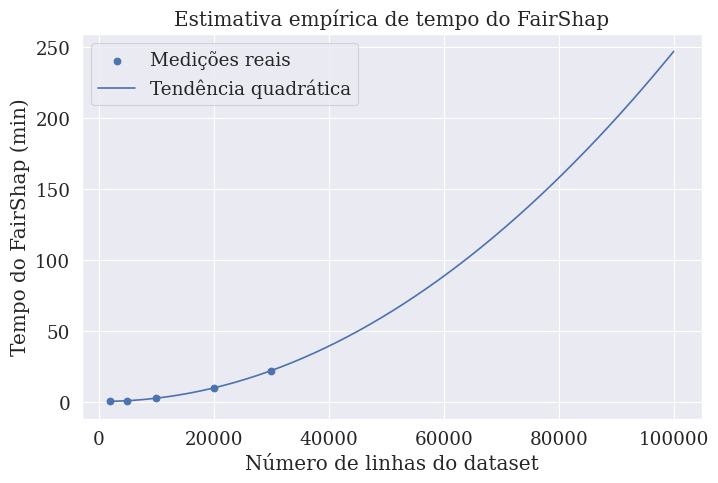

20,000 linhas -> 9.6 min -> 0.16 h
30,000 linhas -> 21.8 min -> 0.36 h
50,000 linhas -> 61.2 min -> 1.02 h
100,000 linhas -> 247.0 min -> 4.12 h
350,000 linhas -> 3045.8 min -> 50.76 h


In [7]:
# ============================================================
# Resultados
# ============================================================

df_tempos = pd.DataFrame(
    resultados_tempo
)

display(df_tempos)



# Ajuste quadrático: tempo ≈ a*n² + b*n + c
coef = np.polyfit(df_tempos["n"], df_tempos["tempo_min"], deg=2)
poly = np.poly1d(coef)

n_linha = np.linspace(
    df_tempos["n"].min(),
    100000,
    200
)

tempo_estimado = poly(n_linha)

plt.figure(figsize=(8, 5))

plt.scatter(
    df_tempos["n"],
    df_tempos["tempo_min"],
    label="Medições reais"
)

plt.plot(
    n_linha,
    tempo_estimado,
    label="Tendência quadrática"
)

plt.xlabel("Número de linhas do dataset")
plt.ylabel("Tempo do FairShap (min)")
plt.title("Estimativa empírica de tempo do FairShap")
plt.legend()
plt.grid(True)
plt.show()


for n_estimado in [20000, 30000, 50000, 100000, 350000]:
    tempo = poly(n_estimado)
    print(f"{n_estimado:,} linhas -> {tempo:.1f} min -> {tempo/60:.2f} h")

# Avaliação modelos

5. Para cada modelo salvo:
   - carregar modelo
   - carregar split/teste
   - calcular métricas